# 02 — CRNN-CTC Model Evaluation

Visual analysis of the best checkpoint from the first training run on **realbook_primus_aa** (clean typeset images).

**Contents:**
1. Training curves (loss + SER)
2. Aggregate test-set metrics
3. SER distribution & sequence-length analysis
4. Sample predictions — best, worst, and random
5. Error-type breakdown (insertions vs deletions vs substitutions)

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────────
from pathlib import Path
NOTEBOOK_DIR = Path("..").resolve()   # project root (TFG-OMR/)

import sys
# Add BOTH the project root (so `src.CRNN_CTC` resolves when unpickling
# checkpoints) AND src/ (so `from CRNN_CTC import ...` works in this notebook)
for _p in [str(NOTEBOOK_DIR), str(NOTEBOOK_DIR / "src")]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import style; style.apply()

import csv
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.amp import autocast
from torch.utils.data import DataLoader

from CRNN_CTC.config import Config
from CRNN_CTC.dataset import OMRDataset, collate_fn, make_splits
from CRNN_CTC.evaluate import _edit_distance, greedy_decode, symbol_error_rate
from CRNN_CTC.model import CRNN
from CRNN_CTC.vocab import Vocabulary

CHECKPOINT  = NOTEBOOK_DIR / "models/best_model.pt"
LOG_PATH    = NOTEBOOK_DIR / "models/training_log.csv"
DATA_DIR    = NOTEBOOK_DIR / "data/realbook_primus_aa"
VOCAB_PATH  = NOTEBOOK_DIR / "src/CRNN_CTC/vocabulary.txt"

cfg = Config()
cfg.vocab_path = VOCAB_PATH
cfg.data_dir   = DATA_DIR
cfg.model_dir  = NOTEBOOK_DIR / "models"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:       {device}")
print(f"Project root: {NOTEBOOK_DIR}")
print(f"Vocab:        {VOCAB_PATH}")
print(f"Checkpoint:   {CHECKPOINT}")


Device:       cuda
Project root: /var/home/pol-linux/Uni/TFG-OMR
Vocab:        /var/home/pol-linux/Uni/TFG-OMR/src/CRNN_CTC/vocabulary.txt
Checkpoint:   /var/home/pol-linux/Uni/TFG-OMR/models/best_model.pt


## 1. Training Curves

Load the CSV training log and plot loss + SER across epochs.

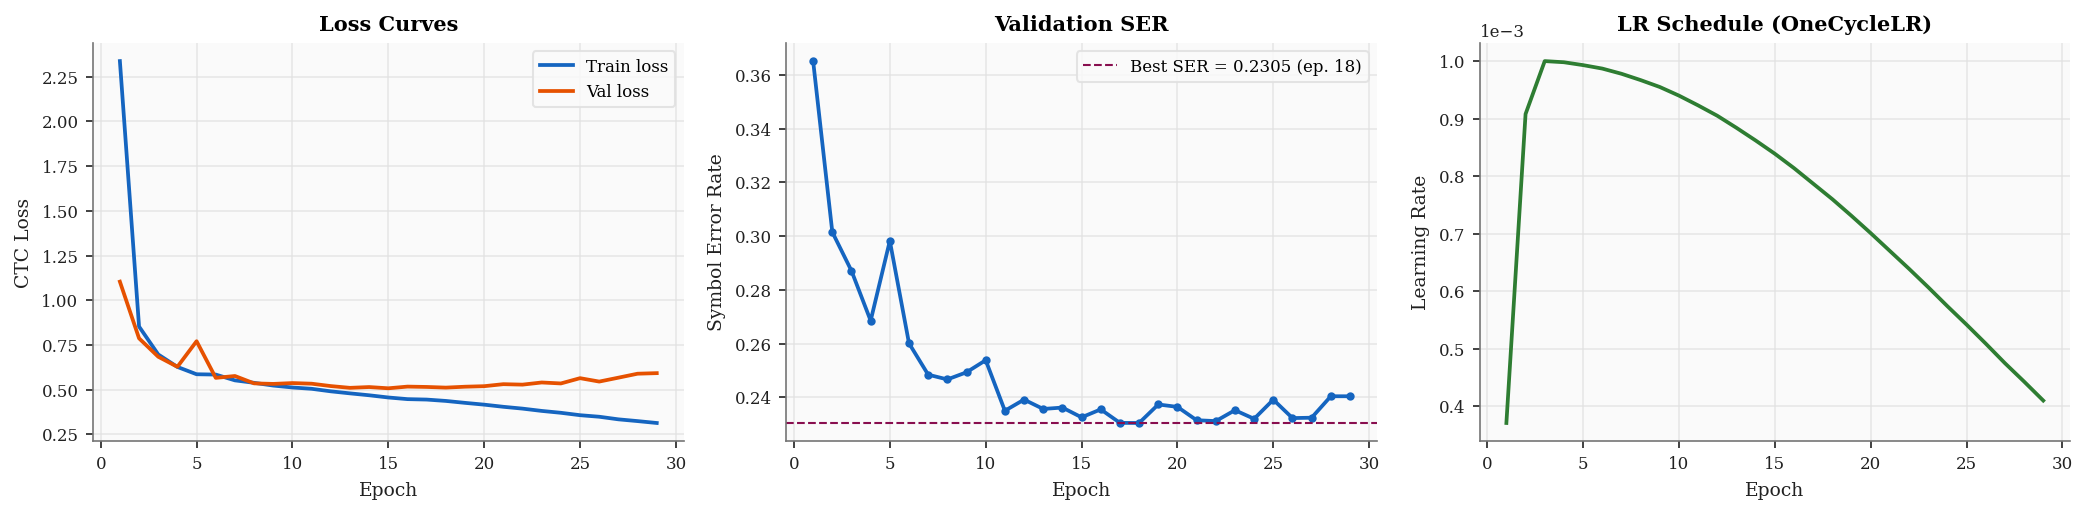

Best val SER: 0.2305 at epoch 18 / 29


In [2]:
# ── Load training log ──────────────────────────────────────────────────────────
with open(LOG_PATH) as f:
    reader = csv.DictReader(f)
    rows = list(reader)

epochs     = [int(r["epoch"]) for r in rows]
train_loss = [float(r["train_loss"]) for r in rows]
val_loss   = [float(r["val_loss"]) for r in rows]
val_ser    = [float(r["val_ser"]) for r in rows]
lr_vals    = [float(r["lr"]) for r in rows]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

ax = axes[0]
ax.plot(epochs, train_loss, label="Train loss", color=style.C["primary"])
ax.plot(epochs, val_loss, label="Val loss", color=style.C["secondary"])
ax.set_xlabel("Epoch"); ax.set_ylabel("CTC Loss"); ax.set_title("Loss Curves"); ax.legend()

ax = axes[1]
ax.plot(epochs, val_ser, color=style.C["primary"], marker="o", markersize=3)
best_epoch = epochs[np.argmin(val_ser)]
best_ser = min(val_ser)
ax.axhline(best_ser, ls="--", color=style.C["highlight"], lw=1,
           label=f"Best SER = {best_ser:.4f} (ep. {best_epoch})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Symbol Error Rate"); ax.set_title("Validation SER"); ax.legend()

ax = axes[2]
ax.plot(epochs, lr_vals, color=style.C["tertiary"])
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning Rate"); ax.set_title("LR Schedule (OneCycleLR)")
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

fig.tight_layout()
plt.show()
print(f"Best val SER: {best_ser:.4f} at epoch {best_epoch} / {max(epochs)}")


## 2. Load Best Checkpoint & Run Inference on Test Split

In [3]:
# ── Load vocab, model, data ────────────────────────────────────────────────────
vocab = Vocabulary.from_file(cfg.vocab_path)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
print(f"Checkpoint: epoch {ckpt['epoch']}, val_SER {ckpt['val_ser']:.4f}")

model = CRNN(
    vocab_size=ckpt.get("vocab_size", len(vocab)),
    cnn_out_channels=cfg.cnn_out_channels,
    rnn_hidden=cfg.rnn_hidden,
    rnn_layers=cfg.rnn_layers,
    dropout=0.0,
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} params")

_, _, test_ds = make_splits(
    data_dir=cfg.data_dir, vocab=vocab, img_height=cfg.img_height,
    val_frac=cfg.val_frac, test_frac=cfg.test_frac, seed=cfg.seed,
)
test_loader = DataLoader(
    test_ds, batch_size=32, shuffle=False,
    num_workers=4, collate_fn=collate_fn, pin_memory=True,
)
print(f"Test set: {len(test_ds)} samples")

Checkpoint: epoch 18, val_SER 0.2305
Model loaded: 4,229,598 params
Test set: 4355 samples


In [4]:
# ── Run inference on full test set ──────────────────────────────────────────────
use_amp = device.type == "cuda"
results: list[dict] = []  # per-sample results

with torch.inference_mode():
    for batch in test_loader:
        images = batch["images"].to(device)
        labels = batch["labels"].to(device)
        label_lens = batch["label_lens"].to(device)
        image_widths = batch["image_widths"].to(device)
        sids = batch["sample_ids"]

        with autocast("cuda", enabled=use_amp):
            log_probs, output_lens = model(images, image_widths)

        preds = greedy_decode(log_probs, output_lens, vocab)

        # Reconstruct per-sample ground truth
        offset = 0
        for i, length in enumerate(label_lens):
            l = length.item()
            ref = vocab.decode(labels[offset : offset + l].tolist())
            offset += l

            ed = _edit_distance(preds[i], ref)
            ser = ed / max(len(ref), 1)
            results.append({
                "sid": sids[i],
                "pred": preds[i],
                "ref": ref,
                "edit_dist": ed,
                "ser": ser,
                "pred_len": len(preds[i]),
                "ref_len": len(ref),
            })

# Sort by SER for later use
results.sort(key=lambda r: r["ser"])
sers = np.array([r["ser"] for r in results])
ref_lens = np.array([r["ref_len"] for r in results])

total_edits = sum(r["edit_dist"] for r in results)
total_syms = sum(r["ref_len"] for r in results)
agg_ser = total_edits / total_syms

print(f"Test SER (aggregate): {agg_ser:.4f}  ({total_edits} edits / {total_syms} symbols)")
print(f"Test SER (mean per-sample): {sers.mean():.4f} ± {sers.std():.4f}")
print(f"Median SER: {np.median(sers):.4f}")
print(f"Samples with SER = 0: {(sers == 0).sum()} / {len(sers)} ({100 * (sers == 0).mean():.1f}%)")
print(f"Samples with SER > 1: {(sers > 1).sum()} / {len(sers)}")

Test SER (aggregate): 0.2251  (57443 edits / 255239 symbols)
Test SER (mean per-sample): 0.1567 ± 0.2113
Median SER: 0.0667
Samples with SER = 0: 1288 / 4355 (29.6%)
Samples with SER > 1: 15 / 4355


## 3. SER Distribution & Sequence-Length Analysis

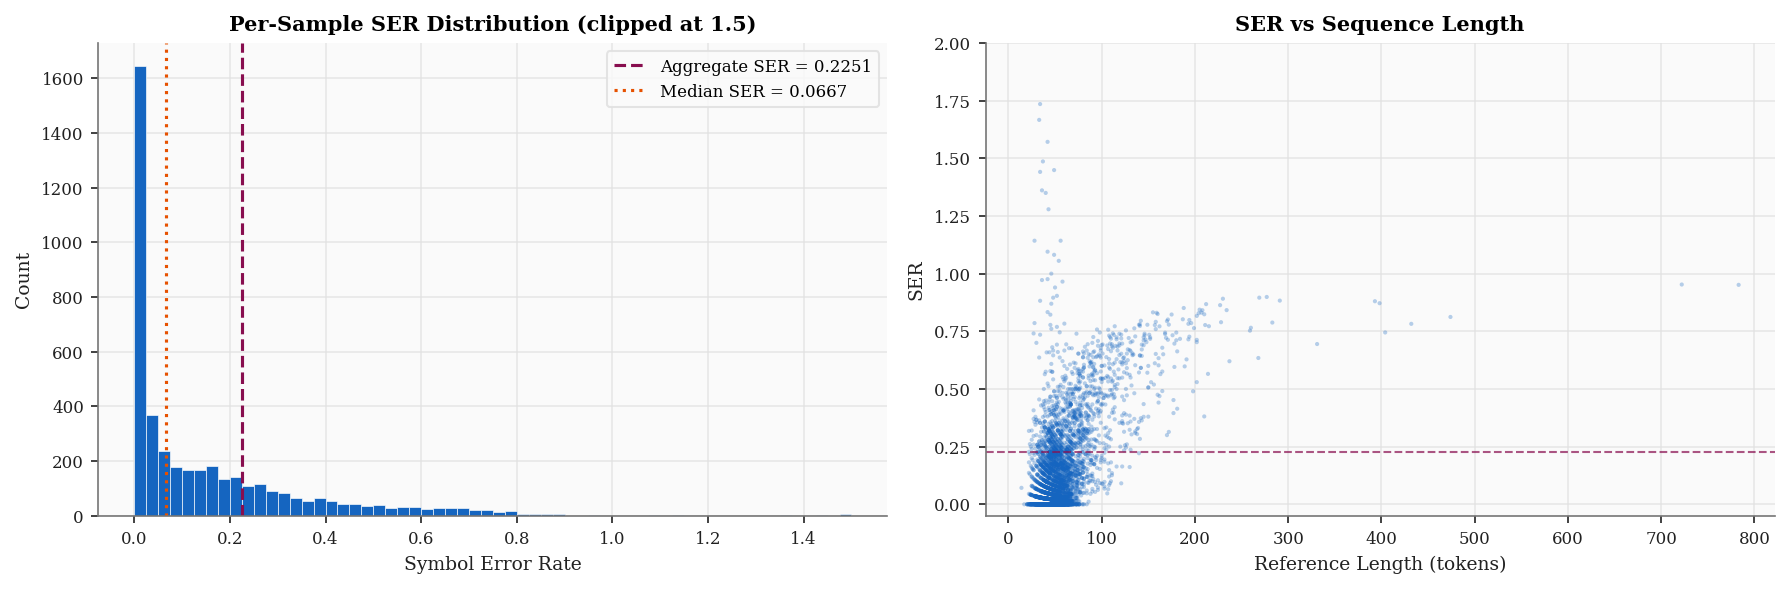

In [5]:
# ── SER histogram + SER vs ref length ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (clip at 1.5 for readability)
ax = axes[0]
clipped = np.clip(sers, 0, 1.5)
ax.hist(clipped, bins=60, color=style.C["primary"], edgecolor="white", linewidth=0.3)
ax.axvline(agg_ser, color=style.C["highlight"], ls="--", lw=1.5,
           label=f"Aggregate SER = {agg_ser:.4f}")
ax.axvline(np.median(sers), color=style.C["secondary"], ls=":", lw=1.5,
           label=f"Median SER = {np.median(sers):.4f}")
ax.set_xlabel("Symbol Error Rate")
ax.set_ylabel("Count")
ax.set_title("Per-Sample SER Distribution (clipped at 1.5)")
ax.legend()

# Scatter: SER vs reference length
ax = axes[1]
ax.scatter(ref_lens, sers, s=4, alpha=0.3, c=style.C["primary"], edgecolors="none")
ax.set_xlabel("Reference Length (tokens)")
ax.set_ylabel("SER")
ax.set_title("SER vs Sequence Length")
ax.set_ylim(-0.05, min(2.0, sers.max() + 0.1))
ax.axhline(agg_ser, color=style.C["highlight"], ls="--", lw=1, alpha=0.7)

fig.tight_layout()
plt.show()

## 4. Sample Predictions — Best, Worst & Random

Show the staff-line image alongside ground truth and predicted token sequences.

In [6]:
def show_prediction(result: dict, *, data_dir: Path = DATA_DIR) -> None:
    """Display the image, ground truth, and predicted tokens for one sample."""
    sid = result["sid"]
    img_path = data_dir / sid / f"{sid}.png"
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    fig, ax = plt.subplots(figsize=(14, 1.8))
    ax.imshow(img, cmap="gray", aspect="auto")
    ax.set_title(
        f"{sid}  —  SER = {result['ser']:.4f}  "
        f"(edit dist = {result['edit_dist']}, ref = {result['ref_len']} tok, "
        f"pred = {result['pred_len']} tok)",
        fontsize=9,
    )
    ax.axis("off")
    plt.show()

    ref_str  = " ".join(result["ref"][:80])
    pred_str = " ".join(result["pred"][:80])
    suffix_ref  = " …" if len(result["ref"])  > 80 else ""
    suffix_pred = " …" if len(result["pred"]) > 80 else ""
    print(f"  REF : {ref_str}{suffix_ref}")
    print(f"  PRED: {pred_str}{suffix_pred}")
    print()


════════════════════════════════════════════════════════════
BEST PREDICTIONS (lowest non-zero SER)
════════════════════════════════════════════════════════════


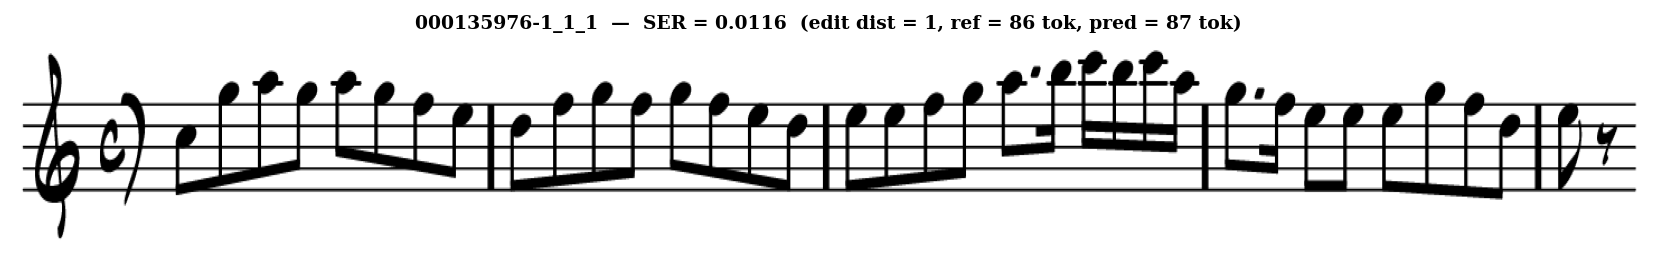

  REF : measure time beats:4 beat-type:4 clef:G2 C5 eighth G5 eighth A5 eighth G5 eighth A5 eighth G5 eighth F5 eighth E5 eighth measure D5 eighth F5 eighth G5 eighth F5 eighth G5 eighth F5 eighth E5 eighth D5 eighth measure E5 eighth E5 eighth F5 eighth G5 eighth A5 eighth dot B5 16th C6 16th B5 16th C6 16th A5 16th measure G5 eighth dot F5 16th E5 eighth E5 eighth E5 eighth G5 eighth F5 eighth D5 eighth measure E5 …
  PRED: measure time beats:4 beat-type:4 clef:G2 C5 eighth G5 eighth A5 eighth G5 eighth A5 eighth G5 eighth F5 eighth E5 eighth measure D5 eighth F5 eighth G5 eighth F5 eighth G5 eighth F5 eighth E5 eighth D5 eighth measure E5 eighth E5 eighth F5 eighth G5 eighth A5 eighth dot B5 16th C6 16th B5 16th C6 16th A5 16th measure G5 eighth dot F5 16th E5 eighth E5 eighth E5 eighth G5 eighth F5 eighth D5 eighth measure E5 …



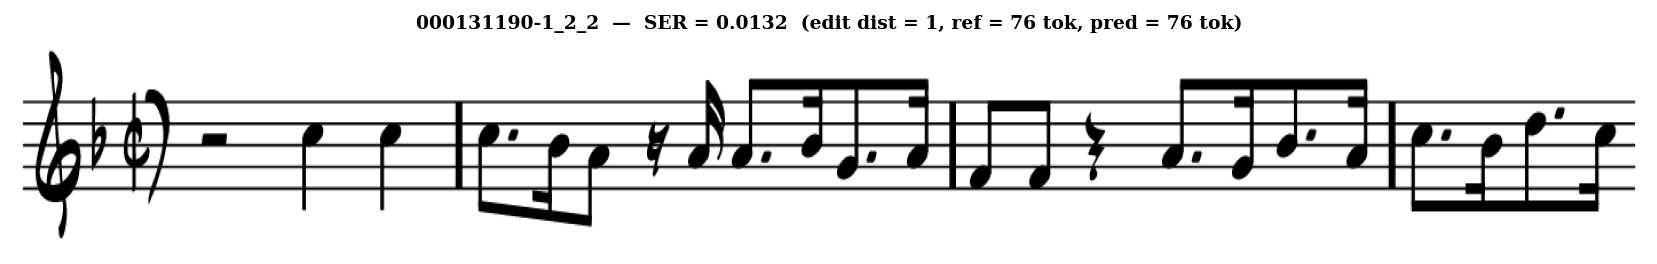

  REF : measure key:fifths:-1 time beats:2 beat-type:2 clef:C1 rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest half C5 quarter C5 quarter measure C5 eighth dot B4 16th A4 eighth rest 16th A4 16th A4 eighth dot B4 16th G4 eighth dot A4 16th measure F4 eighth F4 eighth rest quarter A4 eighth dot G4 16th B4 eighth dot A4 16th measure C5 eighth dot B4 16th D5 eighth dot C5 16th rest half
  PRED: measure key:fifths:-1 time beats:2 beat-type:2 clef:G2 rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest half C5 quarter C5 quarter measure C5 eighth dot B4 16th A4 eighth rest 16th A4 16th A4 eighth dot B4 16th G4 eighth dot A4 16th measure F4 eighth F4 eighth rest quarter A4 eighth dot G4 16th B4 eighth dot A4 16th measure C5 eighth dot B4 16th D5 eighth dot C5 16th rest half



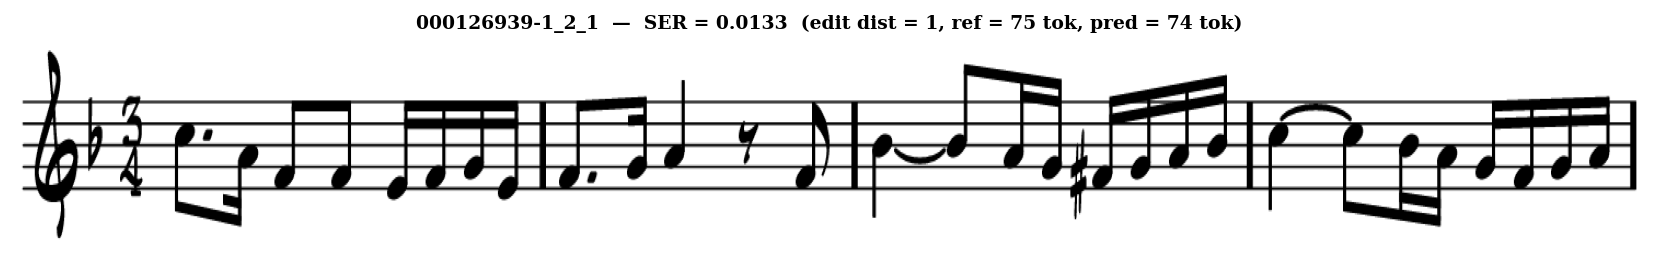

  REF : measure key:fifths:-1 time beats:3 beat-type:4 clef:G2 C5 eighth dot A4 16th F4 eighth F4 eighth E4 16th F4 16th G4 16th E4 16th measure F4 eighth dot G4 16th A4 quarter rest eighth F4 eighth measure B4 quarter tied:start B4 eighth tied:stop A4 16th G4 16th F4 16th sharp G4 16th A4 16th B4 16th measure C5 quarter tied:start C5 eighth tied:stop B4 16th A4 16th G4 16th F4 16th natural G4 16th A4 16th
  PRED: measure key:fifths:-1 time beats:3 beat-type:4 clef:G2 C5 eighth dot A4 16th F4 eighth F4 eighth E4 16th F4 16th G4 16th E4 16th measure F4 eighth dot G4 16th A4 quarter rest eighth F4 eighth measure B4 quarter tied:start B4 eighth tied:stop A4 16th G4 16th F4 16th sharp G4 16th A4 16th B4 16th measure C5 quarter tied:start C5 eighth tied:stop B4 16th A4 16th G4 16th F4 16th G4 16th A4 16th



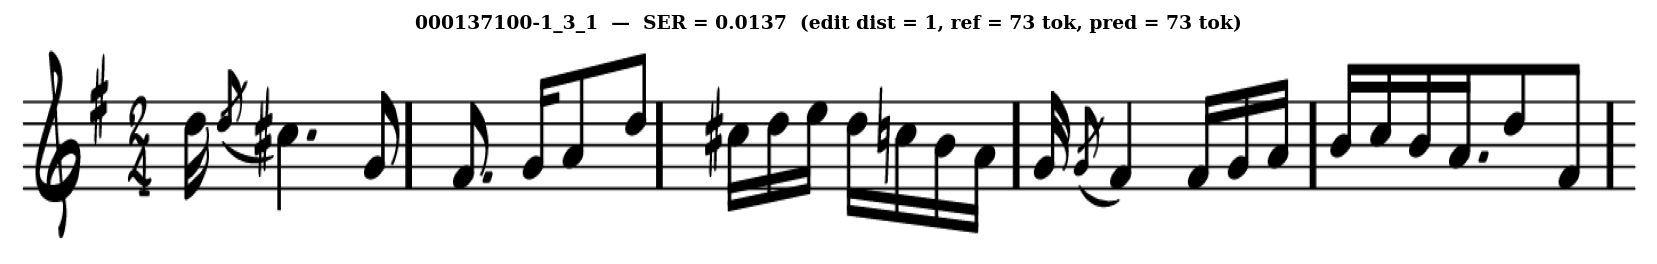

  REF : measure key:fifths:1 time beats:2 beat-type:4 clef:G2 D5 16th rest quarter dot dot measure C5 quarter dot sharp G4 eighth measure F4 eighth dot G4 16th A4 eighth D5 eighth measure C5 16th sharp D5 16th E5 16th D5 16th C5 16th natural B4 16th A4 16th G4 16th measure F4 quarter F4 16th G4 16th A4 16th B4 16th measure C5 16th B4 16th A4 16th dot E5 32nd D5 eighth F4 eighth
  PRED: measure key:fifths:1 time beats:2 beat-type:4 clef:G2 D5 16th rest quarter dot dot measure C5 quarter dot sharp G4 eighth measure F4 eighth dot G4 16th A4 eighth D5 eighth measure C5 16th sharp D5 16th E5 16th D5 16th C5 16th natural B4 16th A4 16th G4 16th measure F4 quarter F4 16th G4 16th A4 16th B4 16th measure C5 16th B4 16th A4 16th dot C5 32nd D5 eighth F4 eighth



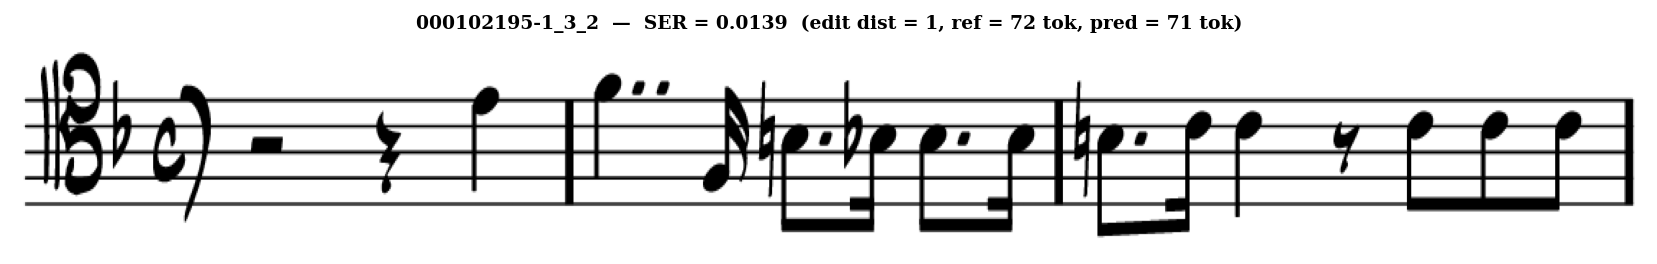

  REF : measure key:fifths:-1 time beats:4 beat-type:4 clef:C4 rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest half rest quarter E4 quarter measure F4 quarter dot dot F3 16th B3 eighth dot natural B3 16th flat B3 eighth dot B3 16th measure B3 eighth dot natural C4 16th C4 quarter rest eighth C4 eighth C4 eighth C4 eighth
  PRED: measure key:fifths:-1 time beats:4 beat-type:4 clef:C4 rest measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest half rest quarter E4 quarter measure F4 quarter dot dot F3 16th B3 eighth dot natural B3 16th flat B3 eighth dot B3 16th measure B3 eighth dot natural C4 16th C4 quarter rest eighth C4 eighth C4 eighth C4 eighth



In [7]:
# ── Best predictions (lowest SER, non-zero for interest) ───────────────────────
print("═" * 60)
print("BEST PREDICTIONS (lowest non-zero SER)")
print("═" * 60)
# `results` is sorted ascending by SER
non_zero = [r for r in results if r["ser"] > 0]
for r in non_zero[:5]:
    show_prediction(r)

════════════════════════════════════════════════════════════
WORST PREDICTIONS (highest SER)
════════════════════════════════════════════════════════════


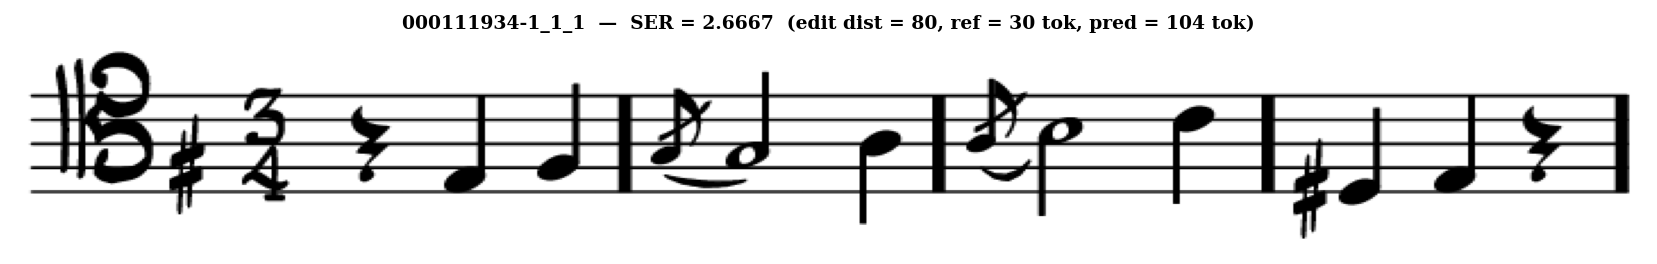

  REF : measure key:fifths:1 time beats:3 beat-type:4 clef:C4 rest quarter E3 quarter F3 quarter measure G3 half A3 quarter measure B3 half C4 quarter measure D3 quarter sharp E3 quarter rest quarter
  PRED: measure key:fifths:1 time beats:3 beat-type:4 clef:C4 rest rest:measure measure rest rest:measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest rest:measure rest rest:measure rest measure rest rest:measure rest quarter measure quarter rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure …



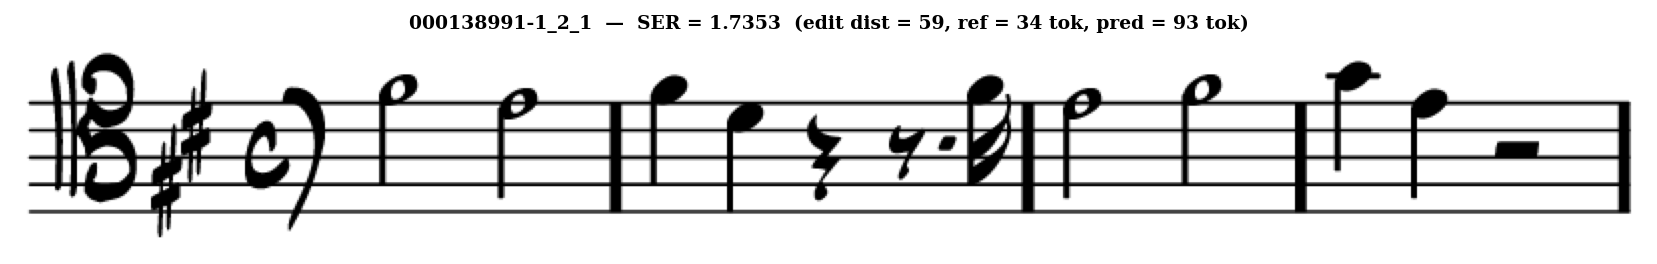

  REF : measure key:fifths:2 time beats:4 beat-type:4 clef:C4 F4 half E4 half measure F4 quarter D4 quarter rest quarter rest eighth dot F4 16th measure E4 half F4 half measure G4 quarter E4 quarter rest half
  PRED: measure key:fifths:2 time beats:4 beat-type:4 clef:C4 rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure F4 half measure rest rest:measure measure rest rest:measure measure rest rest:measure measure measure E4 half measure F4 quarter D4 quarter rest quarter rest eighth dot F4 …



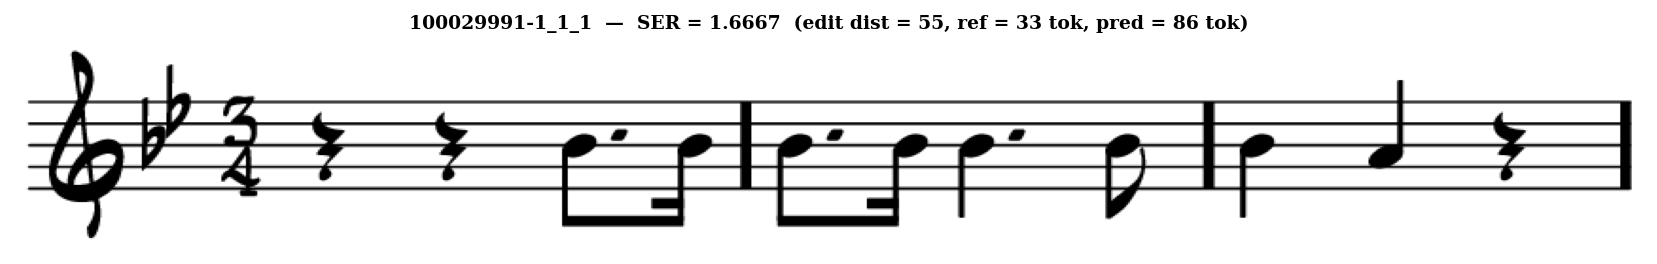

  REF : measure key:fifths:-2 time beats:3 beat-type:4 clef:C1 rest quarter rest quarter B4 eighth dot B4 16th measure B4 eighth dot B4 16th B4 quarter dot B4 eighth measure B4 quarter A4 quarter rest quarter
  PRED: measure key:fifths:-2 time beats:3 beat-type:4 clef:C1 rest rest:measure measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest quarter measure eighth rest:measure rest B4 16th measure rest B4 eighth dot B4 16th B4 quarter dot B4 eighth measure …



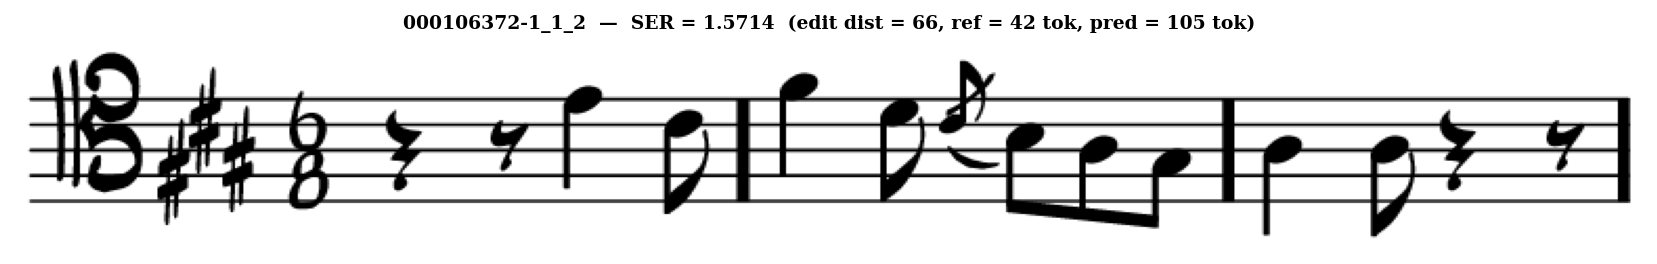

  REF : measure key:fifths:3 time beats:6 beat-type:8 clef:C4 rest rest:measure measure rest rest:measure rest quarter measure rest quarter rest eighth E4 quarter C4 eighth measure F4 quarter D4 eighth B3 eighth A3 eighth G3 eighth measure A3 quarter A3 eighth rest quarter rest eighth
  PRED: measure key:fifths:3 time beats:6 beat-type:8 clef:C4 rest rest:measure measure rest rest:measure rest measure rest rest:measure rest quarter measure rest rest:measure rest quarter rest rest:measure rest quarter rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter measure rest rest:measure rest quarter C4 quarter rest:measure rest rest:measure rest quarter measure F4 quarter …



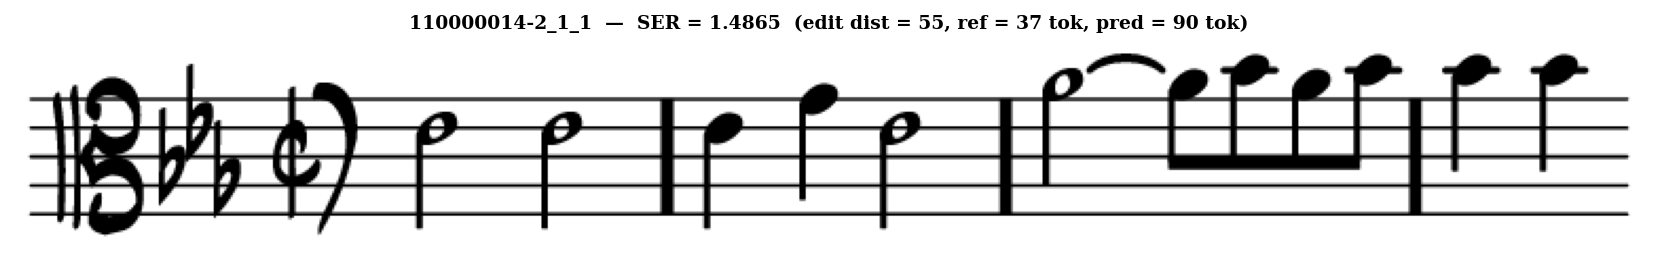

  REF : measure key:fifths:-3 time beats:2 beat-type:2 clef:C3 E4 half E4 half measure E4 quarter G4 quarter E4 half measure A4 half tied:start A4 eighth tied:stop B4 eighth A4 eighth B4 eighth measure B4 quarter B4 quarter rest half
  PRED: measure key:fifths:-3 time beats:2 beat-type:2 clef:C3 rest rest:measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest:measure measure rest:measure measure rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure E4 rest:measure measure rest half measure E4 half measure E4 quarter G4 quarter E4 half measure A4 half tied:start A4 eighth B4 eighth A4 …



In [8]:
# ── Worst predictions (highest SER) ────────────────────────────────────────────
print("═" * 60)
print("WORST PREDICTIONS (highest SER)")
print("═" * 60)
for r in reversed(results[-5:]):
    show_prediction(r)

════════════════════════════════════════════════════════════
RANDOM SAMPLES NEAR MEDIAN SER
════════════════════════════════════════════════════════════


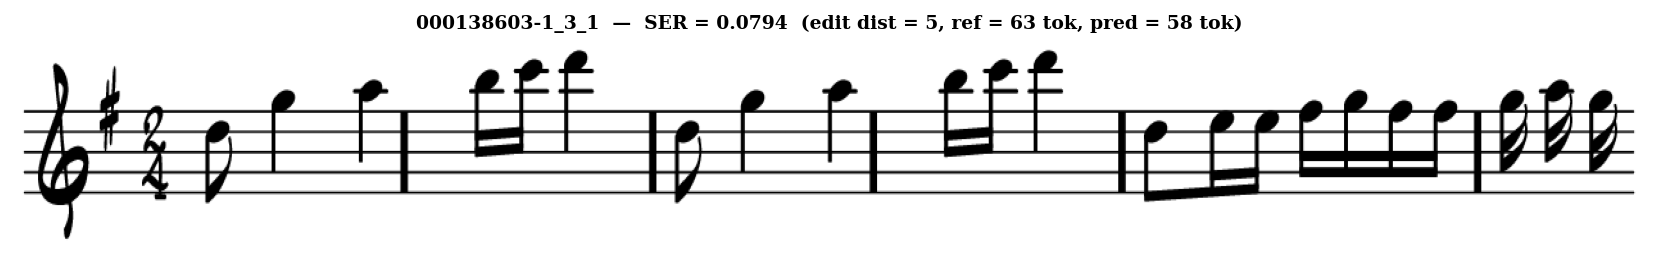

  REF : measure key:fifths:1 time beats:2 beat-type:4 clef:G2 D5 eighth rest quarter dot measure G5 quarter A5 quarter measure B5 16th C6 16th D6 quarter D5 eighth measure G5 quarter A5 quarter measure B5 16th C6 16th D6 quarter D5 eighth measure E5 16th E5 16th F5 16th G5 16th F5 16th F5 16th G5 16th A5 16th measure G5 16th rest quarter dot dot
  PRED: measure key:fifths:1 time beats:2 beat-type:4 clef:G2 D5 eighth rest quarter dot measure G5 quarter A5 quarter measure B5 16th C6 16th D6 quarter D5 eighth measure G5 quarter A5 quarter measure B5 16th C6 16th D6 quarter D5 eighth measure E5 16th E5 16th F5 16th G5 16th F5 16th F5 16th G5 16th A5 16th G5 16th



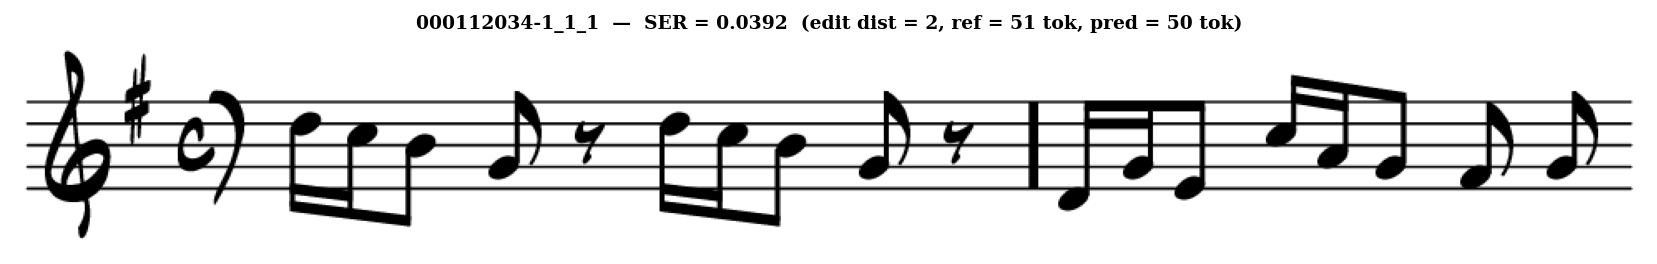

  REF : measure key:fifths:1 time beats:4 beat-type:4 clef:C1 D5 16th C5 16th rest half dot dot measure B4 eighth G4 eighth rest eighth D5 16th C5 16th B4 eighth G4 eighth rest eighth D4 16th G4 16th measure E4 eighth C5 16th A4 16th G4 eighth F4 eighth G4 eighth rest quarter dot
  PRED: measure key:fifths:1 time beats:4 beat-type:4 clef:G2 D5 16th C5 16th rest half dot dot measure B4 eighth G4 eighth rest eighth D5 16th C5 16th B4 eighth G4 eighth rest eighth D4 16th G4 16th measure E4 eighth C5 16th A4 16th G4 eighth F4 eighth G4 eighth rest quarter



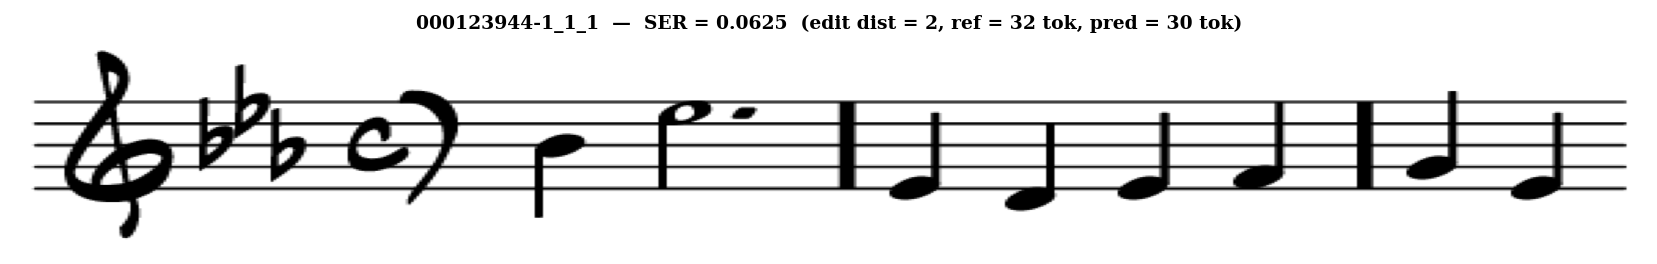

  REF : measure key:fifths:-3 time beats:4 beat-type:4 clef:G2 B4 quarter rest half dot measure E5 half dot E4 quarter measure D4 quarter E4 quarter F4 quarter G4 quarter measure E4 quarter rest half dot
  PRED: measure key:fifths:-3 time beats:4 beat-type:4 clef:G2 B4 quarter rest half dot measure E5 half dot E4 quarter measure D4 quarter E4 quarter F4 quarter G4 quarter E4 quarter rest half



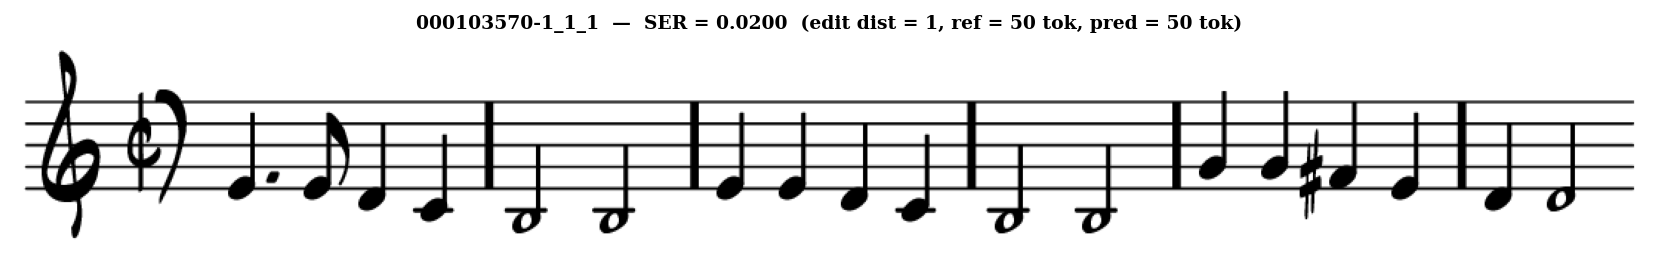

  REF : measure time beats:2 beat-type:2 clef:G2 E4 quarter dot E4 eighth D4 quarter C4 quarter measure B3 half B3 half measure E4 quarter E4 quarter D4 quarter C4 quarter measure B3 half B3 half measure G4 quarter G4 quarter F4 quarter sharp E4 quarter measure D4 quarter D4 half rest quarter
  PRED: measure time beats:2 beat-type:2 clef:G2 E4 quarter dot E4 eighth D4 quarter C4 quarter measure B3 half B3 half measure E4 quarter E4 quarter D4 quarter C4 quarter measure B3 half B3 half measure G4 quarter G4 quarter F4 quarter sharp E4 quarter measure D4 quarter D4 half rest half



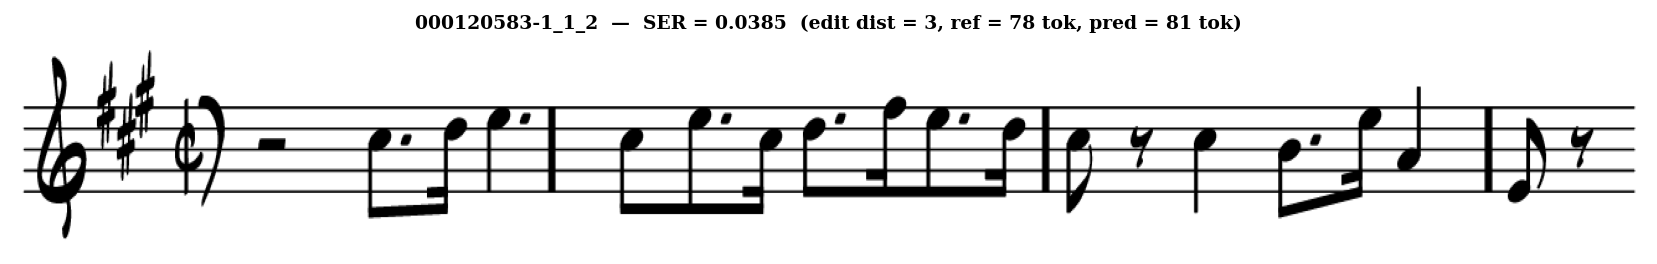

  REF : measure key:fifths:3 time beats:2 beat-type:2 clef:C1 rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest half C5 eighth dot D5 16th rest quarter measure E5 quarter dot C5 eighth E5 eighth dot C5 16th D5 eighth dot F5 16th measure E5 eighth dot D5 16th C5 eighth rest eighth C5 quarter B4 eighth dot E5 16th measure A4 quarter E4 eighth rest eighth rest half
  PRED: measure key:fifths:3 time beats:2 beat-type:2 clef:C1 rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest rest:measure measure rest half C5 eighth dot D5 16th rest quarter measure E5 quarter dot C5 eighth measure E5 eighth dot C5 16th D5 eighth dot F5 16th measure E5 eighth dot D5 16th C5 eighth rest eighth C5 quarter B4 eighth dot E5 16th measure A4 quarter E4

In [9]:
# ── Random samples around the median ───────────────────────────────────────────
print("═" * 60)
print("RANDOM SAMPLES NEAR MEDIAN SER")
print("═" * 60)
rng = np.random.default_rng(42)
median_ser = np.median(sers)
near_median = [r for r in results if abs(r["ser"] - median_ser) < 0.05]
chosen = rng.choice(len(near_median), size=min(5, len(near_median)), replace=False)
for i in chosen:
    show_prediction(near_median[i])

## 5. Error-Type Breakdown

Classify each sample's errors as **insertions** (pred longer), **deletions** (pred shorter), or **substitutions** to understand the dominant failure mode.

Total errors: 57443
  Insertions:      4746  (8.3%)
  Deletions:      43929  (76.5%)
  Substitutions:   8768  (15.3%)


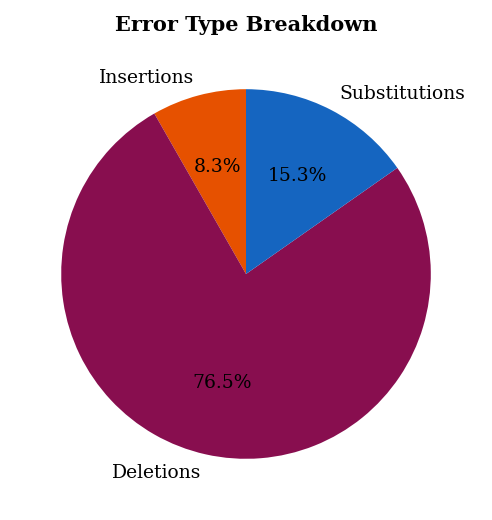

In [10]:
# ── Approximate error decomposition ────────────────────────────────────────────
# For each sample we compute a rough breakdown:
#   min(pred_len, ref_len) alignment positions → substitutions are bounded by
#   the shorter length. The length difference is split between ins/del.

insertions = 0
deletions = 0
substitutions = 0

for r in results:
    ed = r["edit_dist"]
    diff = r["pred_len"] - r["ref_len"]
    if diff > 0:
        insertions += min(diff, ed)
        remaining = max(0, ed - diff)
    elif diff < 0:
        deletions += min(-diff, ed)
        remaining = max(0, ed + diff)
    else:
        remaining = ed
    substitutions += remaining

total_errors = insertions + deletions + substitutions

print(f"Total errors: {total_errors}")
print(f"  Insertions:    {insertions:6d}  ({100*insertions/total_errors:.1f}%)")
print(f"  Deletions:     {deletions:6d}  ({100*deletions/total_errors:.1f}%)")
print(f"  Substitutions: {substitutions:6d}  ({100*substitutions/total_errors:.1f}%)")

# Pie chart
fig, ax = plt.subplots(figsize=(4, 4))
labels = ["Insertions", "Deletions", "Substitutions"]
sizes = [insertions, deletions, substitutions]
colors = [style.C["secondary"], style.C["highlight"], style.C["primary"]]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=90, textprops={"fontsize": 9},
)
ax.set_title("Error Type Breakdown")
plt.show()

## 6. Token-Level Confusion

Which tokens does the model confuse the most? We align predictions to references using the edit distance backtrack and count the top substitution pairs.

In [11]:
from collections import Counter


def _align(hyp: list[str], ref: list[str]) -> list[tuple[str, str | None, str | None]]:
    """Align hyp to ref via Levenshtein backtrack.

    Returns list of (op, hyp_tok, ref_tok):
      - ("match", tok, tok)
      - ("sub", hyp_tok, ref_tok)
      - ("ins", hyp_tok, None)
      - ("del", None, ref_tok)
    """
    n, m = len(hyp), len(ref)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if hyp[i - 1] == ref[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1, dp[i][j - 1] + 1, dp[i - 1][j - 1] + cost)

    # Backtrack
    ops = []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0 and dp[i][j] == dp[i - 1][j - 1] + (0 if hyp[i - 1] == ref[j - 1] else 1):
            if hyp[i - 1] == ref[j - 1]:
                ops.append(("match", hyp[i - 1], ref[j - 1]))
            else:
                ops.append(("sub", hyp[i - 1], ref[j - 1]))
            i -= 1; j -= 1
        elif i > 0 and dp[i][j] == dp[i - 1][j] + 1:
            ops.append(("ins", hyp[i - 1], None))
            i -= 1
        else:
            ops.append(("del", None, ref[j - 1]))
            j -= 1
    return list(reversed(ops))


# Count substitution pairs (skip samples with very long sequences for speed)
sub_counts: Counter = Counter()
ins_counts: Counter = Counter()
del_counts: Counter = Counter()

for r in results:
    if r["ref_len"] > 300:
        continue  # skip degenerate samples
    ops = _align(r["pred"], r["ref"])
    for op, h, ref_tok in ops:
        if op == "sub":
            sub_counts[(h, ref_tok)] += 1
        elif op == "ins":
            ins_counts[h] += 1
        elif op == "del":
            del_counts[ref_tok] += 1

print("Top 15 substitution pairs (pred → ref):")
print("-" * 45)
for (h, r), cnt in sub_counts.most_common(15):
    print(f"  {h:>20s}  →  {r:<20s}  {cnt:>4d}")

print(f"\nTop 10 inserted tokens (hallucinated):")
for tok, cnt in ins_counts.most_common(10):
    print(f"  {tok:>20s}  {cnt:>4d}")

print(f"\nTop 10 deleted tokens (missed):")
for tok, cnt in del_counts.most_common(10):
    print(f"  {tok:>20s}  {cnt:>4d}")

Top 15 substitution pairs (pred → ref):
---------------------------------------------
               clef:G2  →  clef:C1                330
               clef:C1  →  clef:G2                242
               clef:G2  →  measure                150
               quarter  →  eighth                 111
                eighth  →  quarter                 87
                  half  →  quarter                 77
                eighth  →  measure                 67
               clef:C1  →  measure                 59
                eighth  →  16th                    57
               clef:G2  →  clef:G1                 44
               measure  →  quarter                 43
                    B4  →  A4                      42
                    B4  →  C5                      40
               quarter  →  half                    39
                  16th  →  eighth                  39

Top 10 inserted tokens (hallucinated):
               measure  2241
                  rest  1935
      

## 7. Summary Table

In [12]:
# ── Summary ────────────────────────────────────────────────────────────────────
from IPython.display import Markdown

summary = f"""
| Metric | Value |
|--------|-------|
| Checkpoint | `{CHECKPOINT.name}` (epoch {ckpt['epoch']}) |
| Test samples | {len(results):,} |
| **Aggregate SER** | **{agg_ser:.4f}** |
| Mean per-sample SER | {sers.mean():.4f} ± {sers.std():.4f} |
| Median SER | {np.median(sers):.4f} |
| Perfect predictions (SER=0) | {(sers == 0).sum()} ({100*(sers==0).mean():.1f}%) |
| SER > 1 (over-prediction) | {(sers > 1).sum()} ({100*(sers>1).mean():.1f}%) |
| Total edits | {total_edits:,} / {total_syms:,} symbols |
| Model params | {sum(p.numel() for p in model.parameters()):,} |
| Training epochs | {ckpt['epoch']} / {max(epochs)} |
"""
Markdown(summary)


| Metric | Value |
|--------|-------|
| Checkpoint | `best_model.pt` (epoch 18) |
| Test samples | 4,355 |
| **Aggregate SER** | **0.2251** |
| Mean per-sample SER | 0.1567 ± 0.2113 |
| Median SER | 0.0667 |
| Perfect predictions (SER=0) | 1288 (29.6%) |
| SER > 1 (over-prediction) | 15 (0.3%) |
| Total edits | 57,443 / 255,239 symbols |
| Model params | 4,229,598 |
| Training epochs | 18 / 29 |
